# Embeddings to Occupational Space

## Pipeline summary (PCA → polar occupation space, strict run)

This notebook segment **reconstructs a 2D “occupation space” from task embeddings** in the *currently active embeddings run*, then derives **task-, occupation-, and job-family–level coordinates** in both a canonical PC-plane and a **polarized representation** ((\xi,\chi)). It also performs **optional rotational/reflection alignment** to a stored reference and exports **geometry + quality diagnostics** for downstream analysis and plotting.

### 1) Strict run activation and configuration

* Reloads project modules (`infra`, `embeddings`), **activates the most recent run** (fails if none), and loads **run-local configuration** (`year`, `onet_version`, `encoder_name`, encoder id).
* Sets a single **global seed** (`SEED=42`) and defines notebook parameters controlling PCA, radial scaling, and sectorization:

  * PCA: optional common-component removal, optional centering, optional RLE-based weights, 2 components.
  * Polar mapping: (\xi) from angle in the PC-plane (with optional rotation), (\chi) from a fitted radial scale.
  * Discretization: `N_SECTORS` angular bins and `CHI_BINS` radial zones.

### 2) Strict input loading and embedding integrity

* Loads run exports: `tasks_for_pca_base.csv`, `task_embeddings.npy`, and `task_embeddings_fingerprint.json`.
* Validates that the **task texts and embedding matrix match the run fingerprint**, ensuring reproducibility and preventing silent drift.

### 3) Core numeric toolkit

Defines reusable helpers for:

* **(Weighted) PCA** on embeddings, with an optional **common-component subtraction** (via 1D `TruncatedSVD`) and optional **RLE-derived weights**.
* **Polar/Cartesian conversions** and a `RadialScale` abstraction that maps metric radius (r) to plot radius (\chi) using `minmax`, `zero_max`, or quantile scaling (optionally clipped).
* **Sector/zone labels** from (\xi) and (\chi).
* A general **orthogonal 2×2 transform** utility (rotation/reflection) for applying alignment transforms in-place.

### 4) PCA with deterministic caching

* Builds a **cache key** from: the run’s embedding fingerprint + PCA parameters (weights summary, centering, remove-common, component count, shapes/dtypes).
* Loads cached PCA results if (and only if) the stored signature matches; otherwise computes PCA and stores:

  * `XY` (task scores), `V` (loadings), `mu` (center), `var_ratio`.

### 5) Tasks → polar coordinates and discretization

* Writes task scores to `df_tasks` (`pc1`, `pc2`), then constructs:

  * (r=\sqrt{pc1^2+pc2^2})
  * (\xi = \mathrm{atan2}(pc2,pc1)+\mathrm{SECTOR_ROTATION} \pmod{2\pi})
  * (\chi = \mathrm{RadialScale}(r)) (global scale fitted from all tasks)
* Assigns each task to an **angular sector** and **radial zone**, and creates a combined `sector_zone` label.
* Performs a fail-fast check that ((\xi,r)) reconstructs the original ((pc1,pc2)) numerically (i.e., (\chi) is *not* used metrically).

### 6) Occupation and job-family centers (RT-weighted, then equal-occ)

* Builds `df_occ` (occupation centers) by aggregating tasks in the **canonical PC-plane**:

  * Centers are **RT-weighted means** of `(pc1, pc2)` using either **all tasks** or **core-only tasks** (`OCC_CENTER_TASKS`).
  * Adds metadata (`Title`, `Job Family`) from task-level mappings (geometry remains independent of labels).
  * Derives ((\xi,r,\chi)) and sector/zone labels for occupations from their PC-centers.
* Builds `df_fam` (job-family centers) by aggregating **occupation centers with equal weight per occupation** (not proportional to number of tasks):

  * Adds `n_occ_used` and computes a **directionality / angular concentration** statistic (R) for family (\xi) dispersion (`xi_concentration_R`).

### 7) Optional xi-only alignment to a stored reference

* If a reference file exists (`data/procrustes_ref_occupation_embeddings_polar_scaled.csv`), aligns the embedding plane to it using **only angular information**:

  * Fits either **rotation** (\xi_{\text{ref}}\approx \xi_{\text{cur}}+\delta) or **reflection+rotation** (\xi_{\text{ref}}\approx -\xi_{\text{cur}}+\delta), choosing the lower circular RMSE.
  * Applies the resulting **orthogonal transform** to `(pc1, pc2)` for tasks/occupations/families, then recomputes derived polar and sector/zone labels.
  * Stores alignment metadata (`delta`, `reflect`, `det(R)`, RMSE before/after, number of common occupations).

### 8) Exports (schema-preserving) and quality diagnostics

* Exports full-column, key-first CSVs to the **current run’s `exports/`**:

  * `task_embeddings_polar_scaled.csv`
  * `occupation_embeddings_polar_scaled.csv`
  * `job_family_centers_polar_scaled.csv`
* Computes and exports **embedding quality diagnostics**:

  * **Within-occupation task spread**: distances from tasks to occupation center (unweighted + RT-weighted).
  * **Between-occupation separation index**: mean inter-occupation distance divided by mean within-occupation spread.
  * **kNN sanity**: for each occupation, share of its (k) nearest neighbors in the same job family.
  * **Within-family occupation spread** and family **directionality (R)** summary.
  * Exports: overview row, per-occupation table, per-family table, plus a JSON meta definition bundle.

### 9) Visualization outputs (polar map and small multiples)

* Produces a **global polar map** showing sampled tasks (core vs supplemental), occupations colored by job family, and labeled family centers; saves as PNG/PDF under `figures/`, and exports plot-ready rows to `polar_plot_data.csv`.
* Produces **small multiples**: one polar subplot per job family with tasks, occupations, and a robust family center marker; saves PNG/PDF.

In short: the code takes **run-validated task embeddings**, computes a **reproducible cached PCA**, maps tasks/occupations/families into a **canonical 2D plane** and a **polarized occupation space** with sectors/zones, optionally **aligns orientation to a reference**, and exports both **geometry** and **compact quality diagnostics** for analysis and publication-ready plotting.


In [1]:
# === Cell 1: Setup & activate last run (STRICT) ===

import importlib
import numpy as np

import infra
import embeddings  # noqa: F401 (imported for side effects / API availability)

importlib.reload(infra)
importlib.reload(embeddings)

# Activate last run explicitly (strict: errors if none)
infra.activate_last_run(echo=False)

# Load config + encoder spec for the active run (does not create a new run)
RP, cfg, ENCODER_SPEC = infra.load_embeddings_run(strict=True)

# Reproducibility (one place only)
SEED = 42
np.random.seed(SEED)

# Read run parameters from config (single source of truth)
YEAR = int(cfg.get("year", 2025))
ONET_VERSION = str(cfg.get("onet_version", "30_0"))
ENCODER_NAME = str(cfg.get("encoder_name", "")).strip()

print("PROJECT_ROOT :", infra.PROJECT_ROOT)
print("RUNS_ROOT    :", infra.RUNS_ROOT)
print("RUN_TAG      :", infra.RUN_TAG)
print("RUN_DIR      :", infra.RUN_DIR)
print("Exports      :", RP.exports)
print("Cache (run)  :", RP.cache)
print("Cache (glob) :", infra.GLOBAL_CACHE_ROOT)
print("YEAR         :", YEAR)
print("ONET_VERSION :", ONET_VERSION)
print("ENCODER_NAME :", ENCODER_NAME)
print("ENCODER_ID   :", ENCODER_SPEC.embedder_id())
print("SEED         :", SEED)


PROJECT_ROOT : /home/joc/code/geometry-of-work
RUNS_ROOT    : /home/joc/code/geometry-of-work/out/runs
RUN_TAG      : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
RUN_DIR      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
Exports      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
Cache (run)  : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/cache
Cache (glob) : /home/joc/code/geometry-of-work/out/_cache
YEAR         : 2025
ONET_VERSION : 30_1
ENCODER_NAME : openai-3-large
ENCODER_ID   : openai:text-embedding-3-large?dim=3072
SEED         : 42


In [2]:
# === Cell 1b: Notebook config (PCA/polar) ===

import numpy as np

RANDOM_STATE = SEED

SCALER_MODE      = "none"         # {"none", "rle"}
REMOVE_COMMON    = False
PCA_CENTER       = True
N_PCA_COMPONENTS = 2

RADIAL_MODE      = "zero_max"     # {"zero_max", "minmax", "quantile"}
RADIAL_PLOW      = 0.05
RADIAL_PHIGH     = 0.95
RADIAL_CLIP      = True

N_SECTORS        = 36
SECTOR_ROTATION  = 0.0
CHI_BINS         = [0.0, 0.33, 0.66, np.inf]

OCC_CENTER_TASKS = "all"          # {"all", "core"}
RT_COL           = "rt"

print("RUN_TAG      :", infra.RUN_TAG)
print("RUN_DIR      :", infra.RUN_DIR)
print("OCC_CENTER   :", OCC_CENTER_TASKS)
print("RT_COL       :", RT_COL)


RUN_TAG      : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
RUN_DIR      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
OCC_CENTER   : all
RT_COL       : rt


In [3]:
# === Cell 2: Read data (STRICT current run) ===

import numpy as np
import infra
from embeddings import validate_run_embeddings

# RP is already a local variable from Cell 1

FP_TASKS = RP.export_fp("tasks_for_pca_base.csv")
FP_EMB   = RP.export_fp("task_embeddings.npy")
FP_FP    = RP.export_fp("task_embeddings_fingerprint.json")

for p in [FP_TASKS, FP_EMB, FP_FP]:
    if not p.exists():
        raise FileNotFoundError(str(p))

print("tasks_for_pca_base:", FP_TASKS)
print("embeddings (.npy) :", FP_EMB)
print("fingerprint (.json):", FP_FP)

df_tasks = infra.read_csv_any(FP_TASKS)
task_embeddings = np.load(FP_EMB)

print(f"df_tasks rows      : {len(df_tasks):,}")
print("embeddings shape   :", tuple(task_embeddings.shape))

fp = validate_run_embeddings(
    df_tasks["Task"].astype(str).tolist(),
    task_embeddings,
    fp_json=FP_FP,
)

print("✅ Fingerprint OK")
print("  embedder_id  :", fp.get("embedder_id"))
print("  embedder_slug:", fp.get("embedder_slug"))


tasks_for_pca_base: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/tasks_for_pca_base.csv
embeddings (.npy) : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/task_embeddings.npy
fingerprint (.json): /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/task_embeddings_fingerprint.json
df_tasks rows      : 17,606
embeddings shape   : (17606, 3072)
✅ Fingerprint OK
  embedder_id  : openai:text-embedding-3-large?dim=3072
  embedder_slug: openai_text-embedding-3-large_dim_3072


In [4]:
# Cell 3: Hjälpfunktioner för PCA → polar → aggregering → alignment

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.decomposition import TruncatedSVD

import infra  # för read_csv_any


# ---------------------------
# PCA / common component
# ---------------------------
def remove_common_component(X: np.ndarray, random_state: int = 42) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    svd = TruncatedSVD(n_components=1, random_state=random_state)
    c = svd.fit_transform(X)
    v = svd.components_[0]
    return X - (c @ v[None, :])


def build_rle_weights(df: pd.DataFrame, mean_one: bool = True) -> np.ndarray:
    """
    Bygger vikter baserat på rle_mean (Required Level of Education).
    Logg-transform + ev. normalisering till medel = 1.
    """
    w = np.log1p(df["rle_mean"].astype(float).fillna(0).to_numpy())
    w[~np.isfinite(w)] = 0.0
    if mean_one and w.mean() > 0:
        w /= w.mean()
    return w


def weighted_pca(
    X: np.ndarray,
    w: np.ndarray | None,
    k: int = 2,
    remove_common: bool = True,
    center: bool | None = None,   # om None -> använd global PCA_CENTER
    rs: int = 42,
):
    """
    PCA (oviktad eller viktad) på embeddings.
    """
    if center is None:
        center = bool(globals().get("PCA_CENTER", True))

    X0 = X if not remove_common else remove_common_component(X, random_state=rs)

    if w is None:
        if center:
            mu = X0.mean(axis=0)
            Xb = X0 - mu
        else:
            mu = np.zeros(X0.shape[1], dtype=X0.dtype)
            Xb = X0

        U, S, Vt = np.linalg.svd(Xb, full_matrices=False)
        V = Vt.T[:, :k]
        XY = Xb @ V

        ss = (S ** 2)
        var_ratio = (ss / ss.sum())[:k] if ss.sum() > 0 else np.zeros(k)
        return XY, V, mu, var_ratio

    # Viktad
    w = np.asarray(w, float)
    w_sum = float(w.sum())
    if w_sum <= 0:
        raise ValueError("RLE-vikter summerar till 0 — kan inte köra viktad PCA.")

    p = w / w_sum

    if center:
        mu = (p[:, None] * X0).sum(axis=0)
        Xb = X0 - mu
    else:
        mu = np.zeros(X0.shape[1], dtype=X0.dtype)
        Xb = X0

    Cw = (Xb * p[:, None]).T @ Xb

    evals, evecs = np.linalg.eigh(Cw)
    idx = np.argsort(evals)[::-1]
    vals = evals[idx]
    V = evecs[:, idx[:k]]
    XY = Xb @ V
    var_ratio = (vals / vals.sum())[:k] if vals.sum() > 0 else np.zeros(k)

    return XY, V, mu, var_ratio


# ---------------------------
# Sektorer / zoner
# ---------------------------
def sector_zone_labels(xi: np.ndarray, chi: np.ndarray, n_sectors: int, chi_bins: list[float]):
    xi  = np.asarray(xi, dtype=float)
    chi = np.asarray(chi, dtype=float)

    edges = np.linspace(0, 2 * np.pi, int(n_sectors) + 1)

    sec = pd.cut(xi, bins=edges, labels=False, include_lowest=True)
    if isinstance(sec, (pd.Series, pd.Index)):
        sectors_codes = pd.to_numeric(sec, errors="coerce").to_numpy(dtype=float)
    else:
        sectors_codes = np.asarray(sec, dtype=float)

    zones = pd.cut(
        chi,
        bins=chi_bins,
        labels=[f"Z{i}" for i in range(1, len(chi_bins))],
        include_lowest=True,
    )

    return sectors_codes, zones, edges


# ---------------------------
# Tightness / z-mått
# ---------------------------
def make_task_center_pairs(df_tasks: pd.DataFrame, df_occ: pd.DataFrame) -> pd.DataFrame:
    t = df_tasks[["onet_code", "xi", "chi"]].copy()
    tx, ty = _polar_to_xy(t["xi"].to_numpy(), t["chi"].to_numpy())
    t["x"] = tx
    t["y"] = ty

    c = df_occ[["onet_code", "xi", "chi"]].copy()
    cx, cy = _polar_to_xy(c["xi"].to_numpy(), c["chi"].to_numpy())
    c["x_c"] = cx
    c["y_c"] = cy

    tt = t.merge(c, on="onet_code", how="inner")
    tt["d_center"] = np.hypot(tt["x"] - tt["x_c"], tt["y"] - tt["y_c"])
    return tt


def tightness_and_z(df_pairs: pd.DataFrame, p: float = 0.80) -> pd.DataFrame:
    if df_pairs.empty:
        return pd.DataFrame(columns=["onet_code", "z", "tightness", "tight_med", "tight_std", "n_tasks"])

    out = (
        df_pairs.groupby("onet_code")["d_center"]
        .agg(
            z=lambda s: float(np.quantile(s.to_numpy(), p)),
            tightness=lambda s: float(s.mean()),
            tight_med=lambda s: float(np.median(s.to_numpy())),
            tight_std=lambda s: float(s.to_numpy().std(ddof=0)),
            n_tasks="size",
        )
        .reset_index()
    )
    return out


# ---------------------------
# Procrustes-hjälp (referensläsning)
# ---------------------------
def _read_ref_occ(fp: Path) -> pd.DataFrame:
    """
    Läser referensfil för yrkeskoordinater i polär form.
    Förväntar kolumner: onet_code, xi, chi (tolerant för versaler/extra kolumner).
    """
    ref = infra.read_csv_any(fp)
    cols = {c.lower(): c for c in ref.columns}

    need = ["onet_code", "xi", "chi"]
    missing = [c for c in need if c not in cols]
    if missing:
        raise ValueError(f"Saknar kolumner i referensen: {missing}. Hittade: {list(ref.columns)}")

    out = ref[[cols["onet_code"], cols["xi"], cols["chi"]]].copy()
    out.columns = ["onet_code", "xi_ref", "chi_ref"]
    return out.dropna(subset=["onet_code", "xi_ref", "chi_ref"])


In [5]:
# Cell 4: Koordinat-hjälpare (xi,r,chi) + universell XY-rotation
# - xi/r är metriska (från map_x/map_y). chi skapas endast via RadialScale.
# - Inga RP-beroenden. Endast numerik + pandas-safe assignment.

import numpy as np
import pandas as pd
from dataclasses import dataclass

TAU = 2.0 * np.pi


# ----------------------------
# Radial scaling: r <-> chi (plot/zon)
# ----------------------------
@dataclass(frozen=True)
class RadialScale:
    r0: float
    r1: float
    clip: bool = True

    def to_chi(self, r: np.ndarray) -> np.ndarray:
        r = np.asarray(r, dtype=float)
        den = float(self.r1 - self.r0)
        if not np.isfinite(den) or den <= 0:
            chi = np.zeros_like(r, dtype=float)
        else:
            chi = (r - float(self.r0)) / den
        if self.clip:
            chi = np.clip(chi, 0.0, 1.0)
        return chi

    def from_chi(self, chi: np.ndarray) -> np.ndarray:
        chi = np.asarray(chi, dtype=float)
        if self.clip:
            chi = np.clip(chi, 0.0, 1.0)
        return float(self.r0) + chi * (float(self.r1) - float(self.r0))


def fit_radial_scale_from_r(
    r: np.ndarray,
    mode: str = "minmax",
    p_low: float = 0.01,
    p_high: float = 0.99,
    clip: bool = True,
) -> RadialScale:
    r = np.asarray(r, dtype=float)
    r = r[np.isfinite(r)]
    if r.size == 0:
        return RadialScale(0.0, 1.0, clip=bool(clip))

    mode = str(mode).strip().lower()

    if mode == "minmax":
        r0 = float(np.min(r))
        r1 = float(np.max(r))
    elif mode == "zero_max":
        r0 = 0.0
        r1 = float(np.max(r))
    elif mode == "quantile":
        r0 = float(np.quantile(r, float(p_low)))
        r1 = float(np.quantile(r, float(p_high)))
    else:
        raise ValueError(f"Unknown mode: {mode!r}")

    if (not np.isfinite(r0)) or (not np.isfinite(r1)) or (r1 <= r0):
        r0, r1 = 0.0, 1.0

    return RadialScale(r0, r1, clip=bool(clip))


# ----------------------------
# Canonical polar: (x,y) <-> (xi,r)
# ----------------------------
def xy_to_polar(x: np.ndarray, y: np.ndarray, rot: float = 0.0) -> tuple[np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    xi = (np.arctan2(y, x) + float(rot)) % TAU
    r = np.hypot(x, y)
    return xi, r


def polar_to_xy(xi: np.ndarray, r: np.ndarray, rot: float = 0.0) -> tuple[np.ndarray, np.ndarray]:
    xi = (np.asarray(xi, dtype=float) + float(rot)) % TAU
    r = np.asarray(r, dtype=float)
    return r * np.cos(xi), r * np.sin(xi)


def attach_polar(
    df: pd.DataFrame,
    *,
    x_col: str = "map_x",
    y_col: str = "map_y",
    rot: float = 0.0,
    scale: RadialScale | None = None,
    xi_col: str = "xi",
    r_col: str = "r",
    chi_col: str = "chi",
) -> pd.DataFrame:
    """
    Skapar xi och r från (x,y). Skapar chi endast om scale ges.
    Skriver tillbaka i df (in-place).
    """
    if x_col not in df.columns or y_col not in df.columns:
        raise KeyError(f"attach_polar kräver kolumner {x_col!r}, {y_col!r}")

    x = pd.to_numeric(df[x_col], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[y_col], errors="coerce").to_numpy(dtype=float)

    xi, r = xy_to_polar(x, y, rot=float(rot))
    df[xi_col] = xi
    df[r_col] = r

    if scale is not None:
        df[chi_col] = scale.to_chi(r)

    return df


# ----------------------------
# Universal XY rotation: in-place + pure
# ----------------------------
def _as_2x2_orthogonal(R: np.ndarray, *, tol: float = 1e-6) -> np.ndarray:
    R = np.asarray(R, dtype=float)
    if R.shape != (2, 2):
        raise ValueError(f"R måste vara (2,2), fick {R.shape}")
    # fail-fast om den är "för långt" från ortogonal (men utan att vara pedant)
    RtR = R.T @ R
    if not np.allclose(RtR, np.eye(2), atol=tol, rtol=0.0):
        raise ValueError("R verkar inte vara ortogonal (R.T @ R != I inom tolerans).")
    return R


def xy_apply_R(
    df: pd.DataFrame,
    R: np.ndarray,
    xcol: str,
    ycol: str,
    *,
    out_dtype: str = "float64",
    require_cols: bool = False,
) -> pd.DataFrame:
    """
    Applicerar ortogonal 2x2-matris R på kolumner (xcol,ycol) i df, IN-PLACE.
    - Castar kolumnerna till out_dtype innan assignment (undviker dtype-warnings).
    - Om require_cols=False och kolumner saknas: returnerar df oförändrat.
    """
    if xcol not in df.columns or ycol not in df.columns:
        if require_cols:
            raise KeyError(f"Saknar kolumner: {xcol!r}, {ycol!r}")
        return df

    R = _as_2x2_orthogonal(R)

    df[xcol] = pd.to_numeric(df[xcol], errors="coerce").astype(out_dtype)
    df[ycol] = pd.to_numeric(df[ycol], errors="coerce").astype(out_dtype)

    x = df[xcol].to_numpy(dtype=float, copy=False)
    y = df[ycol].to_numpy(dtype=float, copy=False)

    m = np.isfinite(x) & np.isfinite(y)
    if not np.any(m):
        return df

    XY2 = np.column_stack([x[m], y[m]]) @ R
    df.loc[m, xcol] = XY2[:, 0].astype(out_dtype, copy=False)
    df.loc[m, ycol] = XY2[:, 1].astype(out_dtype, copy=False)
    return df


def xy_rotated(x: np.ndarray, y: np.ndarray, R: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    R = _as_2x2_orthogonal(R)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    XY2 = np.column_stack([x, y]) @ R
    return XY2[:, 0], XY2[:, 1]


In [6]:
# Cell 5: PCA (robust cache via task-embedding fingerprint) — updated to new RP (mkpath/get_fp)
import json
import hashlib
import time
import numpy as np

import infra
from infra import read_pkl, write_pkl

t0 = time.perf_counter()
print("▶️  Start: PCA → polar → aggregation → Procrustes → export")

# -----------------------------------------------------------------------------
# 0) Weights (same policy as before)
# -----------------------------------------------------------------------------
w = None if SCALER_MODE == "none" else build_rle_weights(df_tasks, mean_one=False)

# -----------------------------------------------------------------------------
# 1) Read run-local embedding fingerprint
# -----------------------------------------------------------------------------
fp_json = RP.export_fp("task_embeddings_fingerprint.json")   # <- exports/
if not fp_json.exists():
    raise FileNotFoundError(str(fp_json))
fp = json.loads(fp_json.read_text(encoding="utf-8"))

# -----------------------------------------------------------------------------
# 2) Build deterministic cache key from (fingerprint + PCA params)
# -----------------------------------------------------------------------------
def _stable_digest(obj: dict) -> str:
    b = json.dumps(obj, sort_keys=True, ensure_ascii=False, separators=(",", ":")).encode("utf-8")
    return hashlib.blake2s(b, digest_size=16).hexdigest()

pca_sig = {
    "task_embeddings_fp": fp,  # includes hashes + embedder_id/slug/prefix/normalize + batch_size
    "params": {
        "SCALER_MODE": str(SCALER_MODE),
        "N_PCA_COMPONENTS": int(N_PCA_COMPONENTS),
        "REMOVE_COMMON": bool(REMOVE_COMMON),
        "PCA_CENTER": bool(PCA_CENTER),
        "RANDOM_STATE": int(RANDOM_STATE),
        "w_sig": None if w is None else {
            "n": int(len(w)),
            "sum": float(np.sum(w)),
            "mean": float(np.mean(w)),
        },
        "n_rows": int(len(df_tasks)),
        "emb_shape": tuple(map(int, np.asarray(task_embeddings).shape)),
        "emb_dtype": str(np.asarray(task_embeddings).dtype),
    },
}

cache_key = f"pca__{_stable_digest(pca_sig)}"
PCA_CACHE = RP.mkpath("cache", f"{cache_key}.pkl")  # ensures parent exists

# -----------------------------------------------------------------------------
# 3) Load cache if valid; otherwise compute and store
# -----------------------------------------------------------------------------
pca_pack = None
if PCA_CACHE.exists():
    try:
        pca_pack = read_pkl(PCA_CACHE)

        sig_cached = pca_pack.get("sig", None)
        if sig_cached is None:
            raise ValueError("Cache saknar 'sig' — kan inte validera parametrar.")

        params_cached = sig_cached.get("params", {})
        if params_cached.get("REMOVE_COMMON", None) != bool(REMOVE_COMMON):
            raise ValueError("Cache params mismatch: REMOVE_COMMON")
        if params_cached.get("PCA_CENTER", None) != bool(PCA_CENTER):
            raise ValueError("Cache params mismatch: PCA_CENTER")
        if params_cached.get("N_PCA_COMPONENTS", None) != int(N_PCA_COMPONENTS):
            raise ValueError("Cache params mismatch: N_PCA_COMPONENTS")
        if params_cached.get("SCALER_MODE", None) != str(SCALER_MODE):
            raise ValueError("Cache params mismatch: SCALER_MODE")

        fp_cached = sig_cached.get("task_embeddings_fp", None)
        if fp_cached is None:
            raise ValueError("Cache saknar task_embeddings_fp i sig.")
        if fp_cached.get("embedder_id", None) != fp.get("embedder_id", None):
            raise ValueError("Cache fp mismatch: embedder_id")
        if fp_cached.get("texts_sha256", None) != fp.get("texts_sha256", None):
            raise ValueError("Cache fp mismatch: texts_sha256")

        XY = np.asarray(pca_pack["XY"])
        V  = np.asarray(pca_pack["V"])
        mu = np.asarray(pca_pack["mu"])
        var_ratio = np.asarray(pca_pack["var_ratio"])

        n = int(len(df_tasks))
        k = int(N_PCA_COMPONENTS)
        d = int(np.asarray(task_embeddings).shape[1])

        if XY.shape != (n, k):
            raise ValueError(f"Cache XY shape mismatch: {XY.shape} vs {(n, k)}")
        if V.shape != (d, k):
            raise ValueError(f"Cache V shape mismatch: {V.shape} vs {(d, k)}")
        if mu.shape != (d,):
            raise ValueError(f"Cache mu shape mismatch: {mu.shape} vs {(d,)}")
        if var_ratio.shape[0] < k:
            raise ValueError(f"Cache var_ratio shape mismatch: {var_ratio.shape} (need >= {k})")

        print(f"✅ PCA cache HIT: {PCA_CACHE.name}")

    except Exception as e:
        print(f"⚠️  PCA cache läsning misslyckades, räknar om. Orsak: {type(e).__name__}: {e}")
        pca_pack = None

if pca_pack is None:
    XY, V, mu, var_ratio = weighted_pca(
        task_embeddings,
        w,
        k=N_PCA_COMPONENTS,
        remove_common=REMOVE_COMMON,
        center=PCA_CENTER,
        rs=RANDOM_STATE,
    )
    write_pkl(
        PCA_CACHE,
        {
            "XY": np.asarray(XY, dtype=np.float32),
            "V": np.asarray(V, dtype=np.float32),
            "mu": np.asarray(mu, dtype=np.float32),
            "var_ratio": np.asarray(var_ratio, dtype=np.float32),
            "sig": pca_sig,
        },
    )
    print(f"✅ PCA cache MISS → sparad: {PCA_CACHE.name}")

# -----------------------------------------------------------------------------
# 4) Apply results
# -----------------------------------------------------------------------------
df_tasks["pc1"] = XY[:, 0]
df_tasks["pc2"] = XY[:, 1]
PCA_VAR_RATIO = np.asarray(var_ratio)

print(f"✅ PCA klar (mode={'oviktad' if w is None else 'RLE-viktad'}). REMOVE_COMMON={REMOVE_COMMON}.")
print("   Explained variance ratio:", np.round(PCA_VAR_RATIO, 4))

t1 = time.perf_counter()
print(f"⏱️  PCA-cell total: {t1 - t0:.2f}s")


▶️  Start: PCA → polar → aggregation → Procrustes → export
✅ PCA cache MISS → sparad: pca__c10e7c0f2a2e42e339a30286c54dec1f.pkl
✅ PCA klar (mode=oviktad). REMOVE_COMMON=False.
   Explained variance ratio: [0.0417 0.0255]
⏱️  PCA-cell total: 18.76s


In [7]:
# Cell 6: Tasks → KANONISK pc-XY + (xi,r,chi) via universella funktioner (new RP)
# Semantik:
# - pc1/pc2 är KANON (kartesiskt plan).
# - r = hypot(pc1,pc2)
# - xi = atan2(pc2,pc1)+SECTOR_ROTATION
# - chi = R_SCALE.to_chi(r) (plot/zon-radie)

import numpy as np
import pandas as pd
import json

# ----------------------------
# 0) Preconditions
# ----------------------------
if "df_tasks" not in globals() or df_tasks is None:
    raise RuntimeError("df_tasks saknas i globals().")

need = {"pc1", "pc2"}
miss = sorted(need - set(df_tasks.columns))
if miss:
    raise ValueError(f"df_tasks saknar kolumner: {miss}. Kör PCA-cellen först.")

if "attach_polar" not in globals():
    raise RuntimeError("Saknar attach_polar. Definiera i Cell 2b.")
if "fit_radial_scale_from_r" not in globals():
    raise RuntimeError("Saknar fit_radial_scale_from_r. Definiera i Cell 2b.")
if "sector_zone_labels" not in globals() or "N_SECTORS" not in globals() or "CHI_BINS" not in globals():
    raise RuntimeError("Saknar sector_zone_labels/N_SECTORS/CHI_BINS.")

if "RADIAL_MODE" not in globals():
    raise RuntimeError("Saknar RADIAL_MODE (t.ex. 'minmax' | 'zero_max' | 'quantile').")
if "RADIAL_PLOW" not in globals():
    RADIAL_PLOW = 0.01
if "RADIAL_PHIGH" not in globals():
    RADIAL_PHIGH = 0.99
if "RADIAL_CLIP" not in globals():
    RADIAL_CLIP = True

# ----------------------------
# 1) Säkerställ numeric pc-XY (KANON)
# ----------------------------
df_tasks["pc1"] = pd.to_numeric(df_tasks["pc1"], errors="coerce").astype("float64")
df_tasks["pc2"] = pd.to_numeric(df_tasks["pc2"], errors="coerce").astype("float64")

# ----------------------------
# 2) Skapa xi + r från pc-planet (chi senare)
# ----------------------------
attach_polar(
    df_tasks,
    x_col="pc1",
    y_col="pc2",
    rot=float(SECTOR_ROTATION),
    scale=None,          # bara xi,r nu
    xi_col="xi",
    r_col="r",
    chi_col="chi",
)

# ----------------------------
# 3) Fit:a GLOBAL r->chi-skala och skapa chi
# ----------------------------
R_SCALE = fit_radial_scale_from_r(
    df_tasks["r"].to_numpy(float),
    mode=str(RADIAL_MODE),
    p_low=float(RADIAL_PLOW),
    p_high=float(RADIAL_PHIGH),
    clip=bool(RADIAL_CLIP),
)

df_tasks["chi"] = R_SCALE.to_chi(df_tasks["r"].to_numpy(float))
globals()["R_SCALE"] = R_SCALE

# Spara skalan (run-local, strict current run)
try:
    fp_scale = RP.export_fp("radial_scale.json")
    fp_scale.write_text(
        json.dumps(
            {
                "mode": str(RADIAL_MODE),
                "p_low": float(RADIAL_PLOW),
                "p_high": float(RADIAL_PHIGH),
                "r0": float(R_SCALE.r0),
                "r1": float(R_SCALE.r1),
                "clip": bool(R_SCALE.clip),
                "SECTOR_ROTATION": float(SECTOR_ROTATION),
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )
except Exception as e:
    print(f"⚠️ Kunde inte spara radial_scale.json: {type(e).__name__}: {e}")

# ----------------------------
# 4) Sektor/zon (baserat på xi + chi)
# ----------------------------
sectors_codes, zones, sector_edges = sector_zone_labels(
    df_tasks["xi"].to_numpy(float),
    df_tasks["chi"].to_numpy(float),
    int(N_SECTORS),
    list(CHI_BINS),
)

df_tasks["sector"] = pd.Series(sectors_codes, index=df_tasks.index).astype("Int64")
df_tasks["zone"]   = pd.Series(zones, index=df_tasks.index).astype("string").fillna("NA")

sector_str = df_tasks["sector"].map(lambda x: f"{int(x):02d}" if pd.notna(x) else "NA")
df_tasks["sector_zone"] = sector_str + "-" + df_tasks["zone"]

# ----------------------------
# 5) Fail-fast semantikcheck (r ska rekonstruera pc1/pc2, inte chi)
# ----------------------------
rot = float(SECTOR_ROTATION)

chk = df_tasks[["xi", "r", "pc1", "pc2"]].dropna()
if len(chk):
    xi0 = chk["xi"].to_numpy(float) - rot  # ta bort rotationen
    x_rec = chk["r"].to_numpy(float) * np.cos(xi0)
    y_rec = chk["r"].to_numpy(float) * np.sin(xi0)

    dx = chk["pc1"].to_numpy(float) - x_rec
    dy = chk["pc2"].to_numpy(float) - y_rec
    dist = np.sqrt(dx * dx + dy * dy)
    rms = float(np.sqrt(np.mean(dist * dist)))
    mx  = float(np.max(dist))
    print(f"DEBUG: RMS(pc - r*cos/sin): {rms:.3e} | MAX: {mx:.3e}")

print("✅ Polär mappning klar: pc1/pc2 kanoniskt; xi/r härledda; chi via global RadialScale.")
print(f"   R_SCALE: mode={RADIAL_MODE}, r0={R_SCALE.r0:.6g}, r1={R_SCALE.r1:.6g}, clip={R_SCALE.clip}")


DEBUG: RMS(pc - r*cos/sin): 5.760e-17 | MAX: 3.724e-16
✅ Polär mappning klar: pc1/pc2 kanoniskt; xi/r härledda; chi via global RadialScale.
   R_SCALE: mode=zero_max, r0=0, r1=0.457931, clip=True


centers from: all | tasks used: 17,606 / 17,606


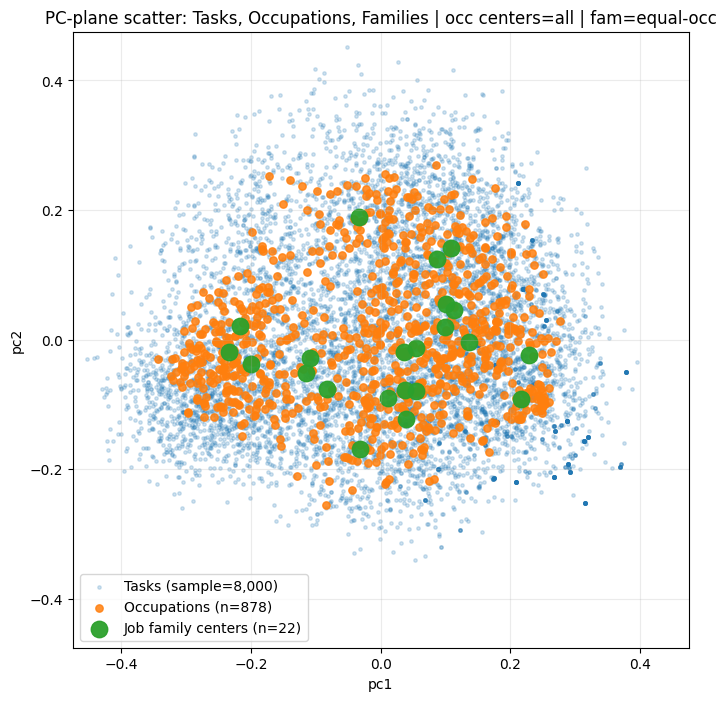

Scatter klart.
  tasks: 17,606 (plotted: 8,000)
  occ:   878
  fam:   22

Key columns:
df_occ: ['onet_code', 'pc1', 'pc2', 'n_tasks_used', 'RT_sum_used', 'Job Family', 'Title', 'xi', 'r', 'chi', 'sector', 'zone', 'sector_zone']
df_fam: ['Job Family', 'pc1', 'pc2', 'n_occ_used', 'xi', 'r', 'chi', 'sector', 'zone', 'sector_zone', 'xi_concentration_R']


In [15]:
# Cell 7: Build df_occ + df_fam from df_tasks (RT-weighted centers in KANON pc-plane)
# - KANON: pc1/pc2
# - OCC_CENTER_TASKS: "core" | "all" (core vs core+supp)
# - RT-weighted centers for df_occ (task mass = RT via RT_COL)
# - df_fam centers from df_occ (each occupation counts equally; independent of #tasks)
# - Job Family/Title mapping ALWAYS from ALL df_tasks
# - df_tasks only filled with missing xi/r/chi/sector/zone/sector_zone if absent

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) Preconditions
# ----------------------------
if "df_tasks" not in globals() or df_tasks is None:
    raise RuntimeError("df_tasks saknas i globals().")

need_tasks = {"onet_code", "pc1", "pc2"}
miss = sorted(need_tasks - set(df_tasks.columns))
if miss:
    raise ValueError(f"df_tasks saknar kolumner: {miss}")

HAS_SECTOR_ZONE = ("sector_zone_labels" in globals()) and ("N_SECTORS" in globals()) and ("CHI_BINS" in globals())

# Global flags (lägg i parametercell vid behov)
OCC_CENTER_TASKS = str(globals().get("OCC_CENTER_TASKS", "all")).lower().strip()  # "all" | "core"
CORE_COL         = str(globals().get("CORE_COL", "is_core"))
RT_COL           = str(globals().get("RT_COL", "rt"))
SECTOR_ROTATION  = float(globals().get("SECTOR_ROTATION", 0.0))

if OCC_CENTER_TASKS not in {"all", "core"}:
    raise ValueError(f"OCC_CENTER_TASKS måste vara 'all' eller 'core', fick: {OCC_CENTER_TASKS!r}")

if RT_COL not in df_tasks.columns:
    raise ValueError(
        f"Saknar RT-kolumn {RT_COL!r} i df_tasks. "
        f"Sätt RT_COL till rätt kolumnnamn eller lägg till RT."
    )

# ----------------------------
# 1) Minimal task table (pc-plane) + RT + label maps (ALL tasks, alltid)
#    OBS: vi standardiserar "massa" till kolumnen RT i tasks0 (oavsett RT_COL)
# ----------------------------
tasks0 = df_tasks[["onet_code", "pc1", "pc2", RT_COL]].copy()

tasks0["pc1"] = pd.to_numeric(tasks0["pc1"], errors="coerce")
tasks0["pc2"] = pd.to_numeric(tasks0["pc2"], errors="coerce")
tasks0["RT"]  = pd.to_numeric(tasks0[RT_COL], errors="coerce")

tasks0 = tasks0.dropna(subset=["onet_code", "pc1", "pc2"])

# RT: NaN/inf/negativa -> 0 (massa kan inte vara <0)
tasks0["RT"] = tasks0["RT"].where(np.isfinite(tasks0["RT"]), 0.0)
tasks0.loc[tasks0["RT"] < 0, "RT"] = 0.0

# Job Family mapping (onet_code -> Job Family) från ALL df_tasks
jobfam_map = None
if "Job Family" in df_tasks.columns:
    jobfam_map = (
        df_tasks[["onet_code", "Job Family"]]
        .dropna(subset=["onet_code", "Job Family"])
        .drop_duplicates(subset=["onet_code"])
    )

# Title mapping (onet_code -> Title) från ALL df_tasks
title_map = None
if "Title" in df_tasks.columns:
    title_map = (
        df_tasks[["onet_code", "Title"]]
        .dropna(subset=["onet_code", "Title"])
        .drop_duplicates(subset=["onet_code"])
    )

# ----------------------------
# 2) Välj vilka tasks som används för att beräkna centra (yrke)
# ----------------------------
tasks_cent = tasks0
if OCC_CENTER_TASKS == "core":
    if CORE_COL not in df_tasks.columns:
        raise ValueError(f"OCC_CENTER_TASKS='core' men df_tasks saknar kolumnen {CORE_COL!r}")

    core_ser = df_tasks.loc[tasks0.index, CORE_COL]  # align till tasks0-rader
    core_m = pd.to_numeric(core_ser, errors="coerce").fillna(0).astype(int) > 0
    tasks_cent = tasks0.loc[core_m].copy()

print(f"centers from: {OCC_CENTER_TASKS} | tasks used: {len(tasks_cent):,} / {len(tasks0):,}")

# ----------------------------
# 3) Helpers: RT-weighted means in pc-plane + polar + sector/zone
# ----------------------------
TAU = 2 * np.pi

def _weighted_center_pc(df: pd.DataFrame, gcol: str, wcol: str = "RT") -> pd.DataFrame:
    """
    RT-weighted center in pc-plane (task mass = RT).
    - If total weight in group == 0: fallback to unweighted mean (warns).
    Returns: [gcol, pc1, pc2, n_tasks_used, RT_sum_used]
    """
    need = {gcol, "pc1", "pc2", wcol}
    miss = sorted(need - set(df.columns))
    if miss:
        raise ValueError(f"_weighted_center_pc: saknar kolumner: {miss}")

    d = df[[gcol, "pc1", "pc2", wcol]].copy()
    d = d.dropna(subset=[gcol, "pc1", "pc2"])
    if d.empty:
        return pd.DataFrame(columns=[gcol, "pc1", "pc2", "n_tasks_used", "RT_sum_used"])

    d["pc1"] = pd.to_numeric(d["pc1"], errors="coerce")
    d["pc2"] = pd.to_numeric(d["pc2"], errors="coerce")
    d[wcol]  = pd.to_numeric(d[wcol], errors="coerce").fillna(0.0)

    d = d.dropna(subset=["pc1", "pc2"])
    
    w = d[wcol].to_numpy(dtype=float, copy=True)
    w[~np.isfinite(w)] = 0.0

    w[w < 0] = 0.0
    d[wcol] = w

    # weighted sums via vectorisation
    d["_wpc1"] = d["pc1"] * d[wcol]
    d["_wpc2"] = d["pc2"] * d[wcol]

    g = d.groupby(gcol, dropna=True)

    out = g.agg(
        RT_sum_used=(wcol, "sum"),
        n_tasks_used=(wcol, "size"),
        _sx=("_wpc1", "sum"),
        _sy=("_wpc2", "sum"),
        _mx=("pc1", "mean"),
        _my=("pc2", "mean"),
    ).reset_index()

    den = out["RT_sum_used"].to_numpy(float)
    use_w = den > 0

    if np.any(~use_w):
        bad = out.loc[~use_w, [gcol, "n_tasks_used"]]
        examples = ", ".join(
            f"{row[gcol]} (n_tasks={int(row['n_tasks_used'])})"
            for _, row in bad.head(8).iterrows()
        )
        more = "" if len(bad) <= 8 else f" … +{len(bad)-8} fler"
        warnings.warn(
            f"[weighted_center_pc] RT_sum_used == 0 → fallback till oviktat medel "
            f"för {len(bad)} grupper. Exempel: {examples}{more}",
            RuntimeWarning,
            stacklevel=2,
        )

    out["pc1"] = np.where(use_w, out["_sx"].to_numpy(float) / den, out["_mx"].to_numpy(float))
    out["pc2"] = np.where(use_w, out["_sy"].to_numpy(float) / den, out["_my"].to_numpy(float))

    return out[[gcol, "pc1", "pc2", "n_tasks_used", "RT_sum_used"]]

def _attach_polar_from_pc(df: pd.DataFrame, xcol="pc1", ycol="pc2", *, rot: float = 0.0):
    x = pd.to_numeric(df[xcol], errors="coerce").to_numpy(float)
    y = pd.to_numeric(df[ycol], errors="coerce").to_numpy(float)

    r  = np.hypot(x, y)
    xi = (np.arctan2(y, x) + float(rot)) % TAU

    df["xi"] = xi
    df["r"]  = r

    if "R_SCALE" in globals() and globals()["R_SCALE"] is not None:
        df["chi"] = globals()["R_SCALE"].to_chi(r)
    else:
        df["chi"] = np.nan

def _attach_sector_zone(df: pd.DataFrame):
    if not HAS_SECTOR_ZONE:
        df["sector"] = pd.Series([pd.NA] * len(df), index=df.index, dtype="Int64")
        df["zone"] = pd.Series(["NA"] * len(df), index=df.index, dtype="string")
        df["sector_zone"] = pd.Series(["NA-NA"] * len(df), index=df.index, dtype="string")
        return

    xi_  = pd.to_numeric(df["xi"],  errors="coerce").to_numpy(float)
    chi_ = pd.to_numeric(df["chi"], errors="coerce").to_numpy(float)

    sec, zon, _ = sector_zone_labels(xi_, chi_, int(N_SECTORS), list(CHI_BINS))

    df["sector"] = pd.Series(sec, index=df.index).astype("Int64")
    df["zone"]   = pd.Series(zon, index=df.index).astype("string").fillna("NA")

    sector_str = df["sector"].map(lambda x: f"{int(x):02d}" if pd.notna(x) else "NA")
    df["sector_zone"] = sector_str + "-" + df["zone"].astype(str)


# ----------------------------
# 4) df_occ: occupation centers (RT-weighted in pc-plane) från tasks_cent
# ----------------------------
df_occ = _weighted_center_pc(tasks_cent, "onet_code", wcol="RT")

_attach_polar_from_pc(df_occ, rot=SECTOR_ROTATION)

# Attach labels (ALL-task mapping; påverkar inte geometri)
if jobfam_map is not None and not jobfam_map.empty:
    df_occ = df_occ.merge(jobfam_map, on="onet_code", how="left")
else:
    df_occ["Job Family"] = pd.NA
    print("ℹ️  'Job Family' saknas i df_tasks → df_occ får Job Family=NA.")

if title_map is not None and not title_map.empty:
    df_occ = df_occ.merge(title_map, on="onet_code", how="left")
else:
    df_occ["Title"] = pd.NA

_attach_sector_zone(df_occ)

globals()["df_occ"] = df_occ

# ----------------------------
# 5) Ensure df_tasks has xi/r/chi + sector/zone/sector_zone (only if missing)
# ----------------------------
need_polar = [c for c in ["xi", "r", "chi"] if c not in df_tasks.columns]
if need_polar:
    _attach_polar_from_pc(df_tasks, xcol="pc1", ycol="pc2", rot=SECTOR_ROTATION)

need_sz = [c for c in ["sector", "zone", "sector_zone"] if c not in df_tasks.columns]
if need_sz:
    _attach_sector_zone(df_tasks)

# ----------------------------
# 6) df_fam: family centers from OCCUPATIONS (each occupation counts equally)
#    + ensure n_occ_used exists (downstream expects a family-size column)
# ----------------------------
occ_f = df_occ.dropna(subset=["Job Family", "pc1", "pc2"]).copy()
occ_f["pc1"] = pd.to_numeric(occ_f["pc1"], errors="coerce")
occ_f["pc2"] = pd.to_numeric(occ_f["pc2"], errors="coerce")
occ_f = occ_f.dropna(subset=["pc1", "pc2"])

df_fam = (
    occ_f.groupby("Job Family", dropna=True, as_index=False)
         .agg(
             pc1=("pc1", "mean"),
             pc2=("pc2", "mean"),
             n_occ_used=("onet_code", "nunique"),
         )
)

# Warn on tiny families (optional but useful)
tiny = df_fam.loc[df_fam["n_occ_used"] < 3, ["Job Family", "n_occ_used"]]
if len(tiny):
    examples = ", ".join(f"{r['Job Family']} (n_occ={int(r['n_occ_used'])})" for _, r in tiny.head(8).iterrows())
    more = "" if len(tiny) <= 8 else f" … +{len(tiny)-8} fler"
    warnings.warn(
        f"[df_fam] Vissa familjer har få occupations (instabila centra): {examples}{more}",
        RuntimeWarning,
        stacklevel=2,
    )

_attach_polar_from_pc(df_fam, rot=SECTOR_ROTATION)
_attach_sector_zone(df_fam)

def _xi_concentration(th: pd.Series) -> float:
    th = pd.to_numeric(th, errors="coerce").to_numpy(float)
    th = th[np.isfinite(th)]
    if th.size == 0:
        return float("nan")
    return float(np.sqrt((np.cos(th).mean())**2 + (np.sin(th).mean())**2))

xiR = (
    occ_f.groupby("Job Family", dropna=True)["xi"]
         .apply(_xi_concentration)
         .rename("xi_concentration_R")
         .reset_index()
)

df_fam = df_fam.merge(xiR, on="Job Family", how="left")

globals()["df_fam"] = df_fam

# ----------------------------
# 7) Plot (pc-plane only)
# ----------------------------
TASK_SAMPLE = int(globals().get("TASK_SAMPLE", 8000))

tasks_plot_src = tasks0[["pc1", "pc2"]].copy()
tasks_plot = tasks_plot_src.sample(n=TASK_SAMPLE, random_state=42) if len(tasks_plot_src) > TASK_SAMPLE else tasks_plot_src

occ_plot_df = df_occ[["pc1", "pc2"]].copy().dropna(subset=["pc1", "pc2"])
fam_plot_df = df_fam[["pc1", "pc2"]].copy().dropna(subset=["pc1", "pc2"])

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(tasks_plot["pc1"], tasks_plot["pc2"], s=6, alpha=0.20,
           label=f"Tasks (sample={len(tasks_plot):,})")

ax.scatter(occ_plot_df["pc1"], occ_plot_df["pc2"], s=28, alpha=0.85,
           label=f"Occupations (n={len(occ_plot_df):,})")

if len(fam_plot_df):
    ax.scatter(fam_plot_df["pc1"], fam_plot_df["pc2"], s=140, alpha=0.95, linewidths=1.0,
               label=f"Job family centers (n={len(fam_plot_df):,})")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("pc1")
ax.set_ylabel("pc2")
ax.set_title(f"PC-plane scatter: Tasks, Occupations, Families | occ centers={OCC_CENTER_TASKS} | fam=equal-occ")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

x_all = np.concatenate([
    tasks_plot["pc1"].to_numpy(),
    occ_plot_df["pc1"].to_numpy(),
    fam_plot_df["pc1"].to_numpy() if len(fam_plot_df) else np.array([], float),
])
y_all = np.concatenate([
    tasks_plot["pc2"].to_numpy(),
    occ_plot_df["pc2"].to_numpy(),
    fam_plot_df["pc2"].to_numpy() if len(fam_plot_df) else np.array([], float),
])
m = np.nanmax(np.abs(np.concatenate([x_all, y_all]))) if (x_all.size or y_all.size) else np.nan
if np.isfinite(m) and m > 0:
    pad = 0.05 * m
    ax.set_xlim(-m - pad, m + pad)
    ax.set_ylim(-m - pad, m + pad)

plt.show()

# ----------------------------
# 8) Summary prints
# ----------------------------
print("Scatter klart.")
print("  tasks:", f"{len(tasks0):,}", "(plotted:", f"{len(tasks_plot):,})")
print("  occ:  ", f"{len(df_occ):,}")
print("  fam:  ", f"{len(df_fam):,}")
n_na = int(df_occ["Job Family"].isna().sum())
if n_na:
    print(f"⚠️  df_occ saknar Job Family för {n_na:,} occupations (påverkar df_fam/legend).")

print("\nKey columns:")
print("df_occ:", [c for c in ["onet_code","pc1","pc2","n_tasks_used","RT_sum_used","Job Family","Title","xi","r","chi","sector","zone","sector_zone"] if c in df_occ.columns])
print("df_fam:", [c for c in ["Job Family","pc1","pc2","n_occ_used","xi","r","chi","sector","zone","sector_zone","xi_concentration_R"] if c in df_fam.columns])


In [16]:
# Cell 8: Align by xi only (rotation + optional reflection), apply to pc1/pc2
# - Fit görs enbart på vinkel (xi) mot referensfilen i data/
# - Hanterar spegling explicit (det(R)=+1 eller -1)
# - Ingen translation, ingen skalning: endast ortogonal 2x2 på pc1/pc2
# - Synkar xi/r/chi från pc1/pc2 efter transform (chi via R_SCALE om den finns)
# - (Valfritt) recompute sector/zone om sector_zone_labels finns
# - Muterar INTE kolumnschema (bara pc1/pc2 + härledda xi/r/chi/sector/zone)

import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------
# 0) Preconditions
# ----------------------------
for name in ["df_tasks", "df_occ", "df_fam"]:
    if name not in globals() or globals()[name] is None:
        raise RuntimeError(f"{name} saknas efter Cell 5.")

for name, need in [
    ("df_tasks", {"pc1", "pc2"}),
    ("df_occ",   {"onet_code", "pc1", "pc2", "xi"}),
    ("df_fam",   {"pc1", "pc2"}),
]:
    miss = sorted(need - set(globals()[name].columns))
    if miss:
        raise ValueError(f"{name} saknar kolumner: {miss}")

SECTOR_ROTATION = float(globals().get("SECTOR_ROTATION", 0.0))
HAS_SECTOR_ZONE = ("sector_zone_labels" in globals()) and ("N_SECTORS" in globals()) and ("CHI_BINS" in globals())

REF_OCC_CSV = RP.project_root / "data" / "procrustes_ref_occupation_embeddings_polar_scaled.csv"

TAU = 2 * np.pi

# ----------------------------
# 1) Helpers
# ----------------------------
def _wrap_pi(a: np.ndarray) -> np.ndarray:
    """Map angle diffs to (-pi, pi]."""
    return (a + np.pi) % (2 * np.pi) - np.pi

def _mean_angle(a: np.ndarray, w: np.ndarray | None = None) -> float:
    """Circular mean angle of a (radians)."""
    a = np.asarray(a, float)
    m = np.isfinite(a)
    if w is None:
        a = a[m]
        if a.size == 0:
            return float("nan")
        return float(np.arctan2(np.sin(a).mean(), np.cos(a).mean()))
    w = np.asarray(w, float)
    mw = m & np.isfinite(w) & (w > 0)
    a = a[mw]; w = w[mw]
    if a.size == 0:
        return float("nan")
    s = np.sum(w)
    if not np.isfinite(s) or s <= 0:
        return float("nan")
    return float(np.arctan2(np.sum(w*np.sin(a))/s, np.sum(w*np.cos(a))/s))

def _circ_rmse(err: np.ndarray, w: np.ndarray | None = None) -> float:
    """RMSE of angular error (already wrapped to (-pi,pi])."""
    e = np.asarray(err, float)
    m = np.isfinite(e)
    if w is None:
        e = e[m]
        return float(np.sqrt(np.mean(e*e))) if e.size else float("nan")
    w = np.asarray(w, float)
    mw = m & np.isfinite(w) & (w > 0)
    e = e[mw]; w = w[mw]
    if e.size == 0:
        return float("nan")
    s = np.sum(w)
    if not np.isfinite(s) or s <= 0:
        return float("nan")
    return float(np.sqrt(np.sum(w*(e*e)) / s))

def _R_from_delta(delta: float, reflect: bool) -> np.ndarray:
    """
    Orto-matris för:
      - reflect=False:  (x,y) -> R_delta @ (x,y)  (ren rotation, det=+1)
      - reflect=True:   (x,y) -> R_delta @ (x,-y) (spegling i x-axeln + rotation, det=-1)
    """
    c, s = float(np.cos(delta)), float(np.sin(delta))
    Rrot = np.array([[c, -s],
                     [s,  c]], dtype=float)
    if not reflect:
        return Rrot
    M = np.array([[1.0, 0.0],
                  [0.0, -1.0]], dtype=float)
    return Rrot @ M

def _apply_R_pc(df: pd.DataFrame, R: np.ndarray, xcol="pc1", ycol="pc2") -> None:
    x = pd.to_numeric(df[xcol], errors="coerce").to_numpy(float)
    y = pd.to_numeric(df[ycol], errors="coerce").to_numpy(float)
    XY = np.column_stack([x, y])
    ok = np.isfinite(XY).all(axis=1)
    if not np.any(ok):
        return
    XY2 = XY.copy()
    XY2[ok] = XY[ok] @ R.T  # (N,2) @ (2,2)
    df[xcol] = XY2[:, 0]
    df[ycol] = XY2[:, 1]

def _sync_polar_from_pc(df: pd.DataFrame) -> None:
    x = pd.to_numeric(df["pc1"], errors="coerce").to_numpy(float)
    y = pd.to_numeric(df["pc2"], errors="coerce").to_numpy(float)
    r  = np.hypot(x, y)
    xi = (np.arctan2(y, x) + float(SECTOR_ROTATION)) % TAU
    df["r"]  = r
    df["xi"] = xi
    if "R_SCALE" in globals() and globals()["R_SCALE"] is not None:
        df["chi"] = globals()["R_SCALE"].to_chi(r)
    else:
        df["chi"] = r  # fallback: metrisk radie

def _assign_sector_zone(df: pd.DataFrame) -> None:
    if not HAS_SECTOR_ZONE:
        return
    xi_  = pd.to_numeric(df["xi"],  errors="coerce").to_numpy(float)
    chi_ = pd.to_numeric(df["chi"], errors="coerce").to_numpy(float)
    sec, zon, _ = sector_zone_labels(xi_, chi_, int(N_SECTORS), list(CHI_BINS))
    df["sector"] = pd.Series(sec, index=df.index).astype("Int64")
    df["zone"]   = pd.Series(zon, index=df.index).astype("string").fillna("NA")
    df["sector_zone"] = (
        df["sector"].map(lambda x: f"{int(x):02d}" if pd.notna(x) else "NA")
        + "-"
        + df["zone"].astype(str)
    )

# ----------------------------
# 2) Read reference + build common set
# ----------------------------
ALIGN_META = {
    "aligned": False,
    "ref_file": str(REF_OCC_CSV),
    "n_common": 0,
    "delta": None,
    "reflect": None,
    "detR": None,
    "rmse_angle_before": None,
    "rmse_angle_after": None,
    "fit_space": "xi_only",
    "notes": None,
}

if not REF_OCC_CSV.exists():
    print(f"ℹ️ Ingen alignment – referensfil saknas: {REF_OCC_CSV}")
    globals()["ALIGN_META"] = ALIGN_META
else:
    ref_raw = pd.read_csv(REF_OCC_CSV)
    if "onet_code" not in ref_raw.columns:
        raise ValueError("Referensen saknar onet_code.")
    if "xi" not in ref_raw.columns:
        raise ValueError("Referensen saknar xi (krävs för xi-only alignment).")

    ref = ref_raw[["onet_code", "xi"]].copy()
    ref["xi_ref"] = pd.to_numeric(ref["xi"], errors="coerce")
    ref = ref.dropna(subset=["onet_code", "xi_ref"])[["onet_code", "xi_ref"]]

    cur = df_occ[["onet_code", "xi"]].copy()
    cur["xi_cur"] = pd.to_numeric(cur["xi"], errors="coerce")
    cur = cur.dropna(subset=["onet_code", "xi_cur"])[["onet_code", "xi_cur"]]

    common = cur.merge(ref, on="onet_code", how="inner")
    n_comm = int(len(common))
    ALIGN_META["n_common"] = n_comm

    if n_comm < 10:
        print(f"ℹ️ För få gemensamma yrken för alignment (n={n_comm}). Hoppar över.")
        ALIGN_META["notes"] = "too_few_common"
        globals()["ALIGN_META"] = ALIGN_META
    else:
        xi_cur = common["xi_cur"].to_numpy(float)
        xi_ref = common["xi_ref"].to_numpy(float)

        # Optional weighting (if you ever want it): use rt_sum_used if available; else unweighted.
        w = None

        # Model A: rotation only => xi_ref ≈ xi_cur + delta
        delta_A = _mean_angle(_wrap_pi(xi_ref - xi_cur), w=w)
        errA0   = _wrap_pi((xi_cur + delta_A) - xi_ref)
        rmseA   = _circ_rmse(errA0, w=w)

        # Model B: reflection + rotation => xi_ref ≈ (-xi_cur) + delta
        delta_B = _mean_angle(_wrap_pi(xi_ref + xi_cur), w=w)
        errB0   = _wrap_pi((-xi_cur + delta_B) - xi_ref)
        rmseB   = _circ_rmse(errB0, w=w)

        # Choose best
        reflect = bool(rmseB < rmseA)
        delta   = float(delta_B if reflect else delta_A)

        # Before/after RMSE (before: no transform)
        err_before = _wrap_pi(xi_cur - xi_ref)
        rmse_before = _circ_rmse(err_before, w=w)

        # Apply chosen model to pc-plane
        R = _R_from_delta(delta, reflect=reflect)
        detR = float(np.linalg.det(R))

        _apply_R_pc(df_tasks, R, "pc1", "pc2")
        _apply_R_pc(df_occ,   R, "pc1", "pc2")
        _apply_R_pc(df_fam,   R, "pc1", "pc2")

        # Recompute polar + sector/zone
        _sync_polar_from_pc(df_tasks); _sync_polar_from_pc(df_occ); _sync_polar_from_pc(df_fam)
        _assign_sector_zone(df_tasks); _assign_sector_zone(df_occ); _assign_sector_zone(df_fam)

        # After: compare xi from updated df_occ vs reference on same common set
        cur2 = df_occ[["onet_code", "xi"]].copy()
        cur2["xi_cur2"] = pd.to_numeric(cur2["xi"], errors="coerce")
        common2 = cur2.merge(ref, on="onet_code", how="inner").dropna(subset=["xi_cur2", "xi_ref"])
        err_after = _wrap_pi(common2["xi_cur2"].to_numpy(float) - common2["xi_ref"].to_numpy(float))
        rmse_after = _circ_rmse(err_after, w=None)

        ALIGN_META.update(
            aligned=True,
            delta=float(delta),
            reflect=reflect,
            detR=detR,
            rmse_angle_before=float(rmse_before),
            rmse_angle_after=float(rmse_after),
        )

        print(
            f"✅ Xi-align mot {Path(REF_OCC_CSV).name} | common={n_comm} | "
            f"reflect={reflect} | det(R)={detR:+.3f} | "
            f"RMSE(angle) {rmse_before:.6f} → {rmse_after:.6f} | delta={delta:.6f} rad"
        )

        globals()["ALIGN_META"] = ALIGN_META


✅ Xi-align mot procrustes_ref_occupation_embeddings_polar_scaled.csv | common=877 | reflect=False | det(R)=+1.000 | RMSE(angle) 0.187355 → 0.187355 | delta=-0.000000 rad


In [17]:
# Cell 9: Export – preserve ALL columns (no loss), new infra/RP
# - Skriver ut df_tasks/df_occ/df_fam med alla befintliga kolumner intakta
# - Säkrar att nyckelkolumner finns och ligger först i filen (resten följer efter)
# - Använder nya RP.mkpath + RP.exports (CURRENT RUN)
# - Ingen koordinatmutation här

import time
from pathlib import Path
import pandas as pd
from infra import RP, write_csv

t0 = time.perf_counter()

def _export_fp(stem: str, suffix: str = ".csv") -> Path:
    # Ny infra: skapa skrivpath i current run, under exports/
    suf = suffix if suffix.startswith(".") else f".{suffix}"
    return RP.mkpath("exports", f"{stem}{suf}")

def _export_preserve_all(df: pd.DataFrame, key_cols: list[str], fp: Path) -> pd.DataFrame:
    out = df.copy()

    # ensure keys exist
    for c in key_cols:
        if c not in out.columns:
            out[c] = pd.NA

    # order: keys first, then all other existing columns (in original order)
    rest = [c for c in out.columns if c not in key_cols]
    out = out[key_cols + rest]

    write_csv(fp, out, index=False)
    return out

# ----------------------------
# Tasks
# ----------------------------
TASK_KEYS = [
    "onet_code",
    "Task ID", "Task", "Task Type", "is_core",
    "rt", "rle_mean",
    "Title", "Job Family",
    "pc1", "pc2",
    "xi", "r", "chi",
    "sector", "zone", "sector_zone",
]
TASK_CSV = _export_fp("task_embeddings_polar_scaled", ".csv")
df_tasks_out = _export_preserve_all(df_tasks, TASK_KEYS, TASK_CSV)

# ----------------------------
# Occupations
# ----------------------------
OCC_KEYS = [
    "onet_code",
    "Title", "Job Family",
    "pc1", "pc2",
    "xi", "r", "chi",
    "sector", "zone", "sector_zone",
]
OCC_CSV = _export_fp("occupation_embeddings_polar_scaled", ".csv")
df_occ_out = _export_preserve_all(df_occ, OCC_KEYS, OCC_CSV)

# ----------------------------
# Families
# ----------------------------
FAM_KEYS = [
    "Job Family",
    # OBS: nya pipeline använder typiskt n_tasks_used + rt_sum_used (inte "n")
    "n_tasks_used", "rt_sum_used",
    "pc1", "pc2",
    "xi", "r", "chi",
    "sector", "zone", "sector_zone",
    "xi_concentration_R",
]
FAM_CSV = _export_fp("job_family_centers_polar_scaled", ".csv")
df_fam_out = _export_preserve_all(df_fam, FAM_KEYS, FAM_CSV)

t1 = time.perf_counter()
print(f"✅ Tasks sparade:        {len(df_tasks_out):,} → {TASK_CSV.name}")
print(f"✅ Yrken sparade:        {len(df_occ_out):,} → {OCC_CSV.name}")
print(f"✅ Job families sparade: {len(df_fam_out):,} → {FAM_CSV.name}")
print(f"📁 Exports-dir (run):    {RP.exports}")
print(f"⏱️  Exportcell: {t1 - t0:.2f}s")


✅ Tasks sparade:        17,606 → task_embeddings_polar_scaled.csv
✅ Yrken sparade:        878 → occupation_embeddings_polar_scaled.csv
✅ Job families sparade: 22 → job_family_centers_polar_scaled.csv
📁 Exports-dir (run):    /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
⏱️  Exportcell: 0.14s


In [18]:
# Cell 10: Embedding quality — compact print + aggregated exports (new infra/RP)
# -----------------------------------------------------------------------------
# Changes vs v1:
#   - Uses new infra RP.mkpath("exports", ...) instead of RP.export_fp(...)
#   - Imports RP from infra; no globals()-check for RP
#   - Exports live under current run's exports/ (RP.exports)
#   - Keeps filenames human-readable and stable
# -----------------------------------------------------------------------------

import json
import numpy as np
import pandas as pd
from pathlib import Path
from infra import RP, write_csv

# ----------------------------
# 0) Preconditions
# ----------------------------
req_tasks = {"onet_code", "pc1", "pc2", "rt"}
req_occ   = {"onet_code", "pc1", "pc2", "Job Family", "Title"}
req_fam   = {"Job Family", "pc1", "pc2", "xi_concentration_R", "n_occ_used"}

miss = sorted(req_tasks - set(df_tasks.columns))
if miss: raise ValueError(f"df_tasks saknar kolumner: {miss}")
miss = sorted(req_occ - set(df_occ.columns))
if miss: raise ValueError(f"df_occ saknar kolumner: {miss}")
miss = sorted(req_fam - set(df_fam.columns))
if miss: raise ValueError(f"df_fam saknar kolumner: {miss}")

# ----------------------------
# 1) Helpers
# ----------------------------
def _as_str(s):
    return s.astype(str).str.strip()

def _safe_arr(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(float)
    return x[np.isfinite(x)]

def _q(x, qs=(0.1, 0.5, 0.9)):
    a = _safe_arr(x)
    if a.size == 0:
        return {f"q{int(100*q)}": np.nan for q in qs}
    out = np.quantile(a, qs)
    return {f"q{int(100*q)}": float(v) for q, v in zip(qs, out)}

def _fmt(x, nd=3):
    try:
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

def _export_fp(stem: str, suffix: str) -> Path:
    suf = suffix if suffix.startswith(".") else f".{suffix}"
    return RP.mkpath("exports", f"{stem}{suf}")

def _export_csv(df: pd.DataFrame, stem: str) -> Path:
    fp = _export_fp(stem, ".csv")
    write_csv(fp, df, index=False)
    return fp

def _export_json(obj, stem: str) -> Path:
    fp = _export_fp(stem, ".json")
    fp.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
    return fp

# ----------------------------
# 2) Prepare local numeric views (NO mutation of original frames)
# ----------------------------
t = df_tasks[list(req_tasks)].copy()
t["onet_code"] = _as_str(t["onet_code"])
t["pc1"] = pd.to_numeric(t["pc1"], errors="coerce")
t["pc2"] = pd.to_numeric(t["pc2"], errors="coerce")
t["rt"]  = pd.to_numeric(t["rt"],  errors="coerce").fillna(0.0).clip(lower=0.0)
t = t.dropna(subset=["onet_code", "pc1", "pc2"])

o = df_occ[list(req_occ)].copy()
o["onet_code"] = _as_str(o["onet_code"])
o["pc1"] = pd.to_numeric(o["pc1"], errors="coerce")
o["pc2"] = pd.to_numeric(o["pc2"], errors="coerce")
o["Job Family"] = o["Job Family"].astype(str).str.strip()
o = o.dropna(subset=["onet_code", "pc1", "pc2"])

f = df_fam[list(req_fam)].copy()
f["Job Family"] = f["Job Family"].astype(str).str.strip()
f["pc1"] = pd.to_numeric(f["pc1"], errors="coerce")
f["pc2"] = pd.to_numeric(f["pc2"], errors="coerce")
f["xi_concentration_R"] = pd.to_numeric(f["xi_concentration_R"], errors="coerce")
f["n"]   = pd.to_numeric(f["n_occ_used"], errors="coerce")
f = f.dropna(subset=["Job Family", "pc1", "pc2"])

# ----------------------------
# 3) A1: Within-occupation task compactness (dist tasks -> occ center)
# ----------------------------
m = t.merge(
    o[["onet_code", "pc1", "pc2"]].rename(columns={"pc1": "occ_pc1", "pc2": "occ_pc2"}),
    on="onet_code",
    how="inner",
)

dx = (m["pc1"].to_numpy(float) - m["occ_pc1"].to_numpy(float))
dy = (m["pc2"].to_numpy(float) - m["occ_pc2"].to_numpy(float))
m["_dist"] = np.sqrt(dx*dx + dy*dy)
m["_w"]    = m["rt"].to_numpy(float)
m["_wd"]   = m["_w"] * m["_dist"]

A1_unw = (
    m.groupby("onet_code", dropna=True)["_dist"]
     .agg(n_tasks_used="size",
          within_occupation_task_spread__mean_dist_to_occ_center="mean",
          within_occupation_task_spread__median_dist_to_occ_center="median")
     .reset_index()
)

A1_w = (
    m.groupby("onet_code", dropna=True)
     .agg(_w_sum=("_w", "sum"),
          _wd_sum=("_wd", "sum"),
          _dist_mean_fallback=("_dist", "mean"))
     .reset_index()
)
A1_w["within_occupation_task_spread__rt_weighted_mean_dist_to_occ_center"] = np.where(
    A1_w["_w_sum"].to_numpy(float) > 0,
    A1_w["_wd_sum"].to_numpy(float) / A1_w["_w_sum"].to_numpy(float),
    A1_w["_dist_mean_fallback"].to_numpy(float),
)

A1 = A1_unw.merge(
    A1_w[["onet_code", "within_occupation_task_spread__rt_weighted_mean_dist_to_occ_center"]],
    on="onet_code", how="left"
)

A1 = A1.merge(
    o[["onet_code", "Title", "Job Family"]].rename(columns={"Title": "occupation_title", "Job Family": "job_family"}),
    on="onet_code", how="left"
).rename(columns={"onet_code": "occupation_id_onet"})

# ----------------------------
# 4) B1: Between-occupation separation (mean inter-occ dist / mean within-occ spread)
# ----------------------------
occ_xy = o[["pc1", "pc2"]].to_numpy(float)
occ_ok = np.isfinite(occ_xy).all(axis=1)
occ_xy = occ_xy[occ_ok]
n_occ_used = int(occ_xy.shape[0])

if n_occ_used >= 2:
    G = occ_xy @ occ_xy.T
    s2 = np.sum(occ_xy * occ_xy, axis=1)
    d2 = (s2[:, None] + s2[None, :] - 2.0 * G)
    d2[d2 < 0] = 0.0
    iu = np.triu_indices(n_occ_used, k=1)
    inter_dist = np.sqrt(d2[iu])
    mean_inter_occ_dist = float(np.nanmean(inter_dist))
else:
    mean_inter_occ_dist = float("nan")

mean_within_occ_spread = float(np.nanmean(A1["within_occupation_task_spread__mean_dist_to_occ_center"].to_numpy(float)))
separation_index__inter_over_intra = (
    mean_inter_occ_dist / mean_within_occ_spread
    if np.isfinite(mean_inter_occ_dist) and np.isfinite(mean_within_occ_spread) and mean_within_occ_spread > 0
    else float("nan")
)

# ----------------------------
# 5) B2: Nearest-neighbor sanity (kNN same-family share)
# ----------------------------
K_NEIGH = 10
occ_ids = o.loc[occ_ok, "onet_code"].to_numpy()
occ_fam = o.loc[occ_ok, "Job Family"].to_numpy(object)

def _nn_same_family_rate(X, fam, k=10):
    X = np.asarray(X, float)
    fam = np.asarray(fam, object)
    n = X.shape[0]
    if n < 3:
        return np.full(n, np.nan), np.nan, np.nan

    G = X @ X.T
    s = np.sum(X * X, axis=1)
    d2 = (s[:, None] + s[None, :] - 2.0 * G)
    d2[d2 < 0] = 0.0
    np.fill_diagonal(d2, np.inf)

    kk = int(min(max(1, k), n - 1))
    nn_idx = np.argpartition(d2, kth=kk-1, axis=1)[:, :kk]

    rates = np.full(n, np.nan, dtype=float)
    for i in range(n):
        fi = fam[i]
        if fi is None or (isinstance(fi, float) and np.isnan(fi)) or str(fi) == "nan":
            continue
        rates[i] = float(np.mean(fam[nn_idx[i]] == fi))
    return rates, float(np.nanmean(rates)), float(np.nanmedian(rates))

B2_rates, B2_mean, B2_median = _nn_same_family_rate(occ_xy, occ_fam, k=K_NEIGH)

B2 = pd.DataFrame({
    "occupation_id_onet": occ_ids.astype(str),
    "job_family": occ_fam,
    f"nearest_neighbor_sanity__share_of_{K_NEIGH}_nearest_occupations_in_same_job_family": B2_rates,
})

df_occ_quality = (
    A1.merge(
        B2[["occupation_id_onet", f"nearest_neighbor_sanity__share_of_{K_NEIGH}_nearest_occupations_in_same_job_family"]],
        on="occupation_id_onet",
        how="left"
    )
)

# ----------------------------
# 6) C1: Family compactness (occ -> family center) + C2: directionality
# ----------------------------
fam_cent = f.set_index("Job Family")[["pc1", "pc2"]]

oo = o.dropna(subset=["Job Family"]).copy()
oo["Job Family"] = oo["Job Family"].astype(str).str.strip()
oo = oo[oo["Job Family"].isin(fam_cent.index)]

dx = oo["pc1"].to_numpy(float) - fam_cent.loc[oo["Job Family"], "pc1"].to_numpy(float)
dy = oo["pc2"].to_numpy(float) - fam_cent.loc[oo["Job Family"], "pc2"].to_numpy(float)
oo["_dist_to_fam_center"] = np.sqrt(dx*dx + dy*dy)

C1 = (
    oo.groupby("Job Family", dropna=True)["_dist_to_fam_center"]
      .agg(
          within_family_occupation_spread__mean_dist_to_family_center="mean",
          within_family_occupation_spread__median_dist_to_family_center="median",
          n_occupations_in_family_used="count",
      )
      .reset_index()
      .rename(columns={"Job Family": "job_family"})
)

df_family_quality = (
    C1.merge(
        f.rename(columns={"Job Family": "job_family", "n": "n_occupations_in_family_total"})[
            ["job_family", "n_occupations_in_family_total", "xi_concentration_R"]
        ],
        on="job_family",
        how="left"
    )
    .rename(columns={"xi_concentration_R": "family_directionality__xi_concentration_R"})
)

mean_family_spread = float(np.nanmean(df_family_quality["within_family_occupation_spread__mean_dist_to_family_center"].to_numpy(float)))
mean_xi_conc = float(np.nanmean(df_family_quality["family_directionality__xi_concentration_R"].to_numpy(float)))
share_xi_ge_07 = float(np.nanmean((df_family_quality["family_directionality__xi_concentration_R"].to_numpy(float) >= 0.7).astype(float)))

# ----------------------------
# 7) Aggregated overview (single-row) + meta (JSON)
# ----------------------------
q_within = _q(df_occ_quality["within_occupation_task_spread__mean_dist_to_occ_center"])
q_nn     = _q(df_occ_quality[f"nearest_neighbor_sanity__share_of_{K_NEIGH}_nearest_occupations_in_same_job_family"])
q_famrad = _q(df_family_quality["within_family_occupation_spread__mean_dist_to_family_center"])
q_xiconc = _q(df_family_quality["family_directionality__xi_concentration_R"])

df_overview = pd.DataFrame([{
    "n_tasks_used": int(len(t)),
    "n_occupations_used": int(len(df_occ_quality)),
    "n_job_families_used": int(len(df_family_quality)),

    "A_within_occ__mean_task_spread_mean_over_occupations": float(np.nanmean(df_occ_quality["within_occupation_task_spread__mean_dist_to_occ_center"].to_numpy(float))),
    "A_within_occ__mean_task_spread_q10": q_within["q10"],
    "A_within_occ__mean_task_spread_q50": q_within["q50"],
    "A_within_occ__mean_task_spread_q90": q_within["q90"],

    "B_between_occ__mean_inter_occupation_distance": mean_inter_occ_dist,
    "B_between_occ__separation_index_inter_over_intra": separation_index__inter_over_intra,

    f"B_neighbors__mean_share_of_{K_NEIGH}_nn_in_same_family": B2_mean,
    f"B_neighbors__median_share_of_{K_NEIGH}_nn_in_same_family": B2_median,
    "B_neighbors__same_family_share_q10": q_nn["q10"],
    "B_neighbors__same_family_share_q50": q_nn["q50"],
    "B_neighbors__same_family_share_q90": q_nn["q90"],

    "C_family__mean_family_spread_mean_over_families": mean_family_spread,
    "C_family__family_spread_q10": q_famrad["q10"],
    "C_family__family_spread_q50": q_famrad["q50"],
    "C_family__family_spread_q90": q_famrad["q90"],

    "C_family__mean_directionality_R_mean_over_families": mean_xi_conc,
    "C_family__directionality_R_q10": q_xiconc["q10"],
    "C_family__directionality_R_q50": q_xiconc["q50"],
    "C_family__directionality_R_q90": q_xiconc["q90"],
    "C_family__share_families_R_ge_0p7": share_xi_ge_07,
}])

meta = {
    "definitions": {
        "A_within_occ__task_compactness": "Distances from tasks (pc1,pc2) to occupation center (pc1,pc2). Lower means tasks cluster more tightly within an occupation.",
        "B_between_occ__separation_index_inter_over_intra": "Mean distance between occupation centers divided by mean within-occupation task spread.",
        "B_neighbors__knn_same_family_share": f"For each occupation, share of its {K_NEIGH} nearest occupations that are in the same Job Family.",
        "C_family__family_spread": "Distances from occupations to their Job Family center (pc1,pc2). Lower means the family is more compact.",
        "C_family__directionality_R": "Angular concentration in xi (R). Higher means stronger shared direction within family.",
    },
    "parameters": {"k_nearest_neighbors": int(K_NEIGH)},
    "counts": {
        "n_tasks_used": int(len(t)),
        "n_occupations_used": int(len(df_occ_quality)),
        "n_job_families_used": int(len(df_family_quality)),
    },
    "overview": df_overview.iloc[0].to_dict(),
}

# ----------------------------
# 8) Minimal print (compact)
# ----------------------------
print("\n=== Embedding quality (compact) ===")
print(f"Used: tasks={len(t):,} | occupations={len(df_occ_quality):,} | job families={len(df_family_quality):,}")
print(f"A) Within-occupation task spread (mean over occ): {_fmt(df_overview.loc[0, 'A_within_occ__mean_task_spread_mean_over_occupations'])} "
      f"[q10/q50/q90={_fmt(q_within['q10'])}/{_fmt(q_within['q50'])}/{_fmt(q_within['q90'])}]")
print(f"B) Separation index (inter / intra): {_fmt(separation_index__inter_over_intra)} "
      f"(mean inter-occ dist={_fmt(mean_inter_occ_dist)})")
print(f"B) kNN same-family share (k={K_NEIGH}): mean={_fmt(B2_mean)} "
      f"[q10/q50/q90={_fmt(q_nn['q10'])}/{_fmt(q_nn['q50'])}/{_fmt(q_nn['q90'])}]")
print(f"C) Family spread (mean over fam): {_fmt(mean_family_spread)} "
      f"[q10/q50/q90={_fmt(q_famrad['q10'])}/{_fmt(q_famrad['q50'])}/{_fmt(q_famrad['q90'])}]")
print(f"C) Family directionality R: mean={_fmt(mean_xi_conc)} | share(R>=0.7)={_fmt(share_xi_ge_07, nd=2)}")

# ----------------------------
# 9) Exports (few, readable) — new infra/RP
# ----------------------------
paths = {}
paths["overview_csv"]        = _export_csv(df_overview, "embedding_quality__overview")
paths["per_occupation_csv"]  = _export_csv(df_occ_quality, "embedding_quality__per_occupation")
paths["per_job_family_csv"]  = _export_csv(df_family_quality, "embedding_quality__per_job_family")
paths["meta_json"]           = _export_json(meta, "embedding_quality__meta")

globals()["EMB_QUALITY__per_occupation"] = df_occ_quality
globals()["EMB_QUALITY__per_job_family"] = df_family_quality
globals()["EMB_QUALITY__overview"] = df_overview
globals()["EMB_QUALITY__meta"] = meta
globals()["EMB_QUALITY__exports"] = paths

print("\n✅ Exported (current run exports/):")
print(f"📁 {RP.exports}")
for k, p in paths.items():
    print(f"  - {k}: {p.name}")



=== Embedding quality (compact) ===
Used: tasks=17,606 | occupations=878 | job families=22
A) Within-occupation task spread (mean over occ): 0.112 [q10/q50/q90=0.083/0.112/0.139]
B) Separation index (inter / intra): 2.156 (mean inter-occ dist=0.241)
B) kNN same-family share (k=10): mean=0.297 [q10/q50/q90=0.000/0.200/0.700]
C) Family spread (mean over fam): 0.078 [q10/q50/q90=0.049/0.078/0.093]
C) Family directionality R: mean=0.793 | share(R>=0.7)=0.68

✅ Exported (current run exports/):
📁 /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
  - overview_csv: embedding_quality__overview.csv
  - per_occupation_csv: embedding_quality__per_occupation.csv
  - per_job_family_csv: embedding_quality__per_job_family.csv
  - meta_json: embedding_quality__meta.json
